# Tree sequences with RELATE

In [48]:
# load in the relevant packages
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np
from pathlib import Path

And a bit to make the plots look nicer in vscode:

In [57]:
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme()
sns.set_palette('tab10')
plt.set_cmap('tab10')

<Figure size 500x370 with 0 Axes>


# Positive selection

In this exercise we will work on inference of selection using the Relate tool that we also used in the [exercise about tree sequences](https://github.com/kaspermunch/PopulationGenomicsCourse/tree/master/Exercises/tree_sequences). In that exercise we analyzed individuals from three populations and inferred all the trees along the chr2 region we have been working on. In this exercise we are going to use those trees to take the analysis a step further and look for positive selection in our chr2 region. So we pick up the [tree sequences exercise](https://github.com/kaspermunch/PopulationGenomicsCourse/tree/master/Exercises/tree_sequences) where we left it and you should continue this exericse in the same folder. That way you have access to the files you you produced the other exercise.

## Request an interactive session on a compute node:

Begin by requesting a shell on a compute node:

```bash
srun --mem-per-cpu=5g --time=3:00:00 --account=populationgenomics --pty pixi shell
```

Since we already have the trees along our genomic alignment we can now use Relate to analyze each tree and compute the likelihood that it was shaped by positive selection. But before running the analysis you need to make sure you understand how Relate quantifies evidence of selection and how that lines up with what you know about positive selection. Team up with one or more fellow students and make sure you understand the relevant Methods section in the [Relate paper](https://www.nature.com/articles/s41588-019-0484-x) as well as the section "A tree-based statistic for detecting positive selection" in the [supplementary note for the paper](https://static-content.springer.com/esm/art%3A10.1038%2Fs41588-019-0484-x/MediaObjects/41588_2019_484_MOESM1_ESM.pdf).

In [58]:
%%bash
ln -sf ~/populationgenomics/data/relate_data/20140520.chr2.strict_mask.fasta
ln -sf ~/populationgenomics/data/relate_data/genetic_map_chr2_combined_b37.txt
ln -sf ~/populationgenomics/data/relate_data/human_ancestor_2.fa
ln -sf ~/populationgenomics/data/relate_data/60_inds.txt
ln -sf ~/populationgenomics/data/relate_data/chr2_130_145_phased.vcf.gz


The Relate command below detects positive selection. At this point, we are detecting selection based on three distinct populations. 

```bash
DetectSelection.sh -i ../relate-tree-exercise/gbr_relate -m 1.25e-8 --poplabels ../relate-tree-exercise/gbr_inds.txt -o gbr_relate
DetectSelection.sh -i ../relate-tree-exercise/jpt_relate -m 1.25e-8 --poplabels ../relate-tree-exercise/jpt_inds.txt -o jpt_relate
DetectSelection.sh -i ../relate-tree-exercise/yri_relate -m 1.25e-8 --poplabels ../relate-tree-exercise/yri_inds.txt -o yri_relate
```

Have a look at the `gbr_relate.sele` produced, and see what is in there.

In [59]:
gbr_df = pd.read_csv('gbr_relate.sele', sep=' ')
gbr_df.head()

,pos,rs_id,3571428.500000,357142.937500,257030.656250,184981.281250,133128.375000,95810.585938,68953.507812,49624.847656,...,257.030640,184.981262,133.128357,95.810577,68.953499,49.624844,35.714287,0.000000,when_DAF_is_half,when_mutation_has_freq2
0,130000272,rs4662641,1,1,1,1,1,1,1.0,1.0,...,-0.342257,-0.125905,0.0,0.0,0.0,0.0,0.0,0,-0.233469,-0.147982
1,130001121,rs72850340,1,1,1,1,1,1,1.0,1.0,...,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1,1.000000,1.000000
2,130001315,rs185373520,1,1,1,1,1,1,1.0,1.0,...,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1,1.000000,1.000000
3,130001725,rs10167178,1,1,1,1,1,1,1.0,1.0,...,-0.342257,-0.125905,0.0,0.0,0.0,0.0,0.0,0,-0.233469,-0.147982
4,130002073,rs1441141,1,1,1,1,1,1,1.0,1.0,...,-0.342257,-0.125905,0.0,0.0,0.0,0.0,0.0,0,-0.233469,-0.147982


You can use the `usecols` argument to specify which columns to read in, which can speed up the loading process if the file is large and you only need a subset of the columns. Read in the files for both the GBR, JPT and YRI populations:

In [60]:
cols = ['pos', 'rs_id', 'when_mutation_has_freq2']
gbr_df = pd.read_csv('gbr_relate.sele', sep=' ', usecols=cols).set_index('rs_id')
jpt_df = pd.read_csv('jpt_relate.sele', sep=' ', usecols=cols).set_index('rs_id')
yri_df = pd.read_csv('yri_relate.sele', sep=' ', usecols=cols).set_index('rs_id')

gbr_df.head()

,pos,when_mutation_has_freq2
rs_id,,
rs4662641,130000272,-0.147982
rs72850340,130001121,1.000000
rs185373520,130001315,1.000000
rs10167178,130001725,-0.147982
rs1441141,130002073,-0.147982


The last column is the log10 p-value for the test for selection described in the paper.

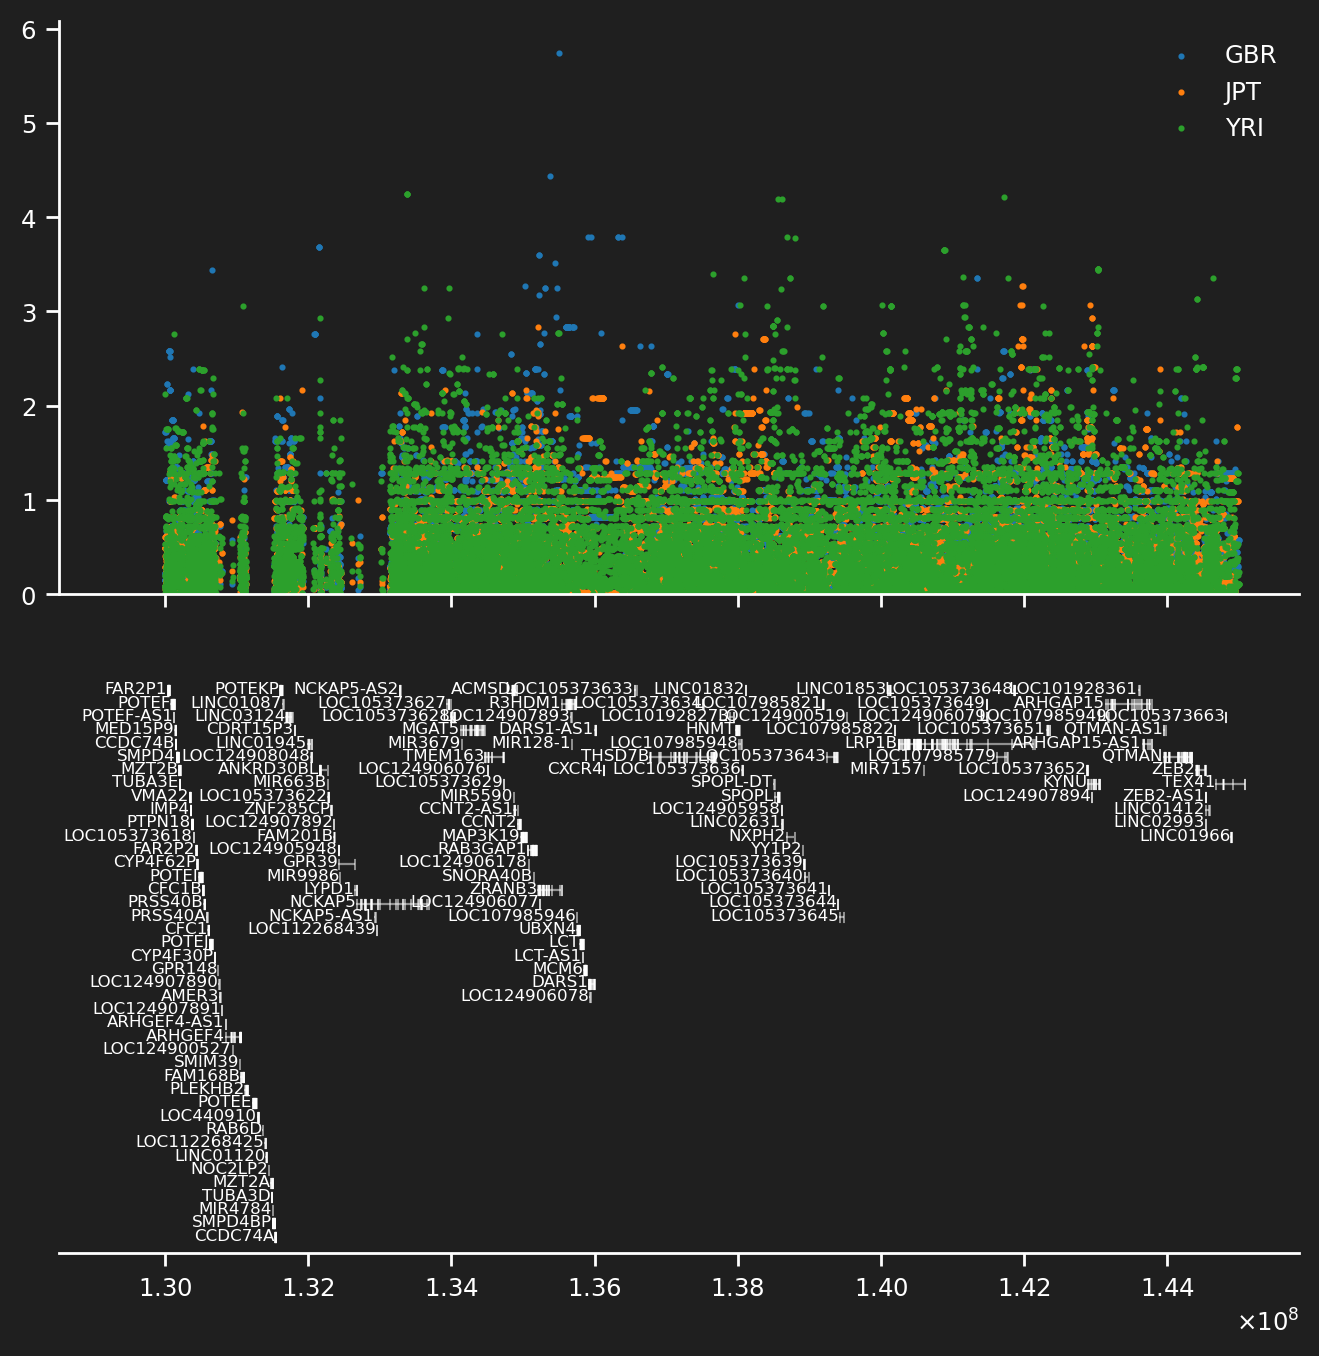

In [61]:
from geneinfo.plot import gene_plot

with vscode_theme(style='ticks'):
    ax = gene_plot('chr2', 130_000_000, 145_000_000, 'hg38', figsize=(8, 8))
    ax.scatter(gbr_df.pos, - gbr_df.when_mutation_has_freq2, s=2, c='tab:blue', label='GBR')
    ax.scatter(jpt_df.pos, - jpt_df.when_mutation_has_freq2, s=2, c='tab:orange', label='JPT')
    ax.scatter(yri_df.pos, - yri_df.when_mutation_has_freq2, s=2, c='tab:green', label='YRI')
    ax.set_ylim(bottom=0)
    ax.legend() ;

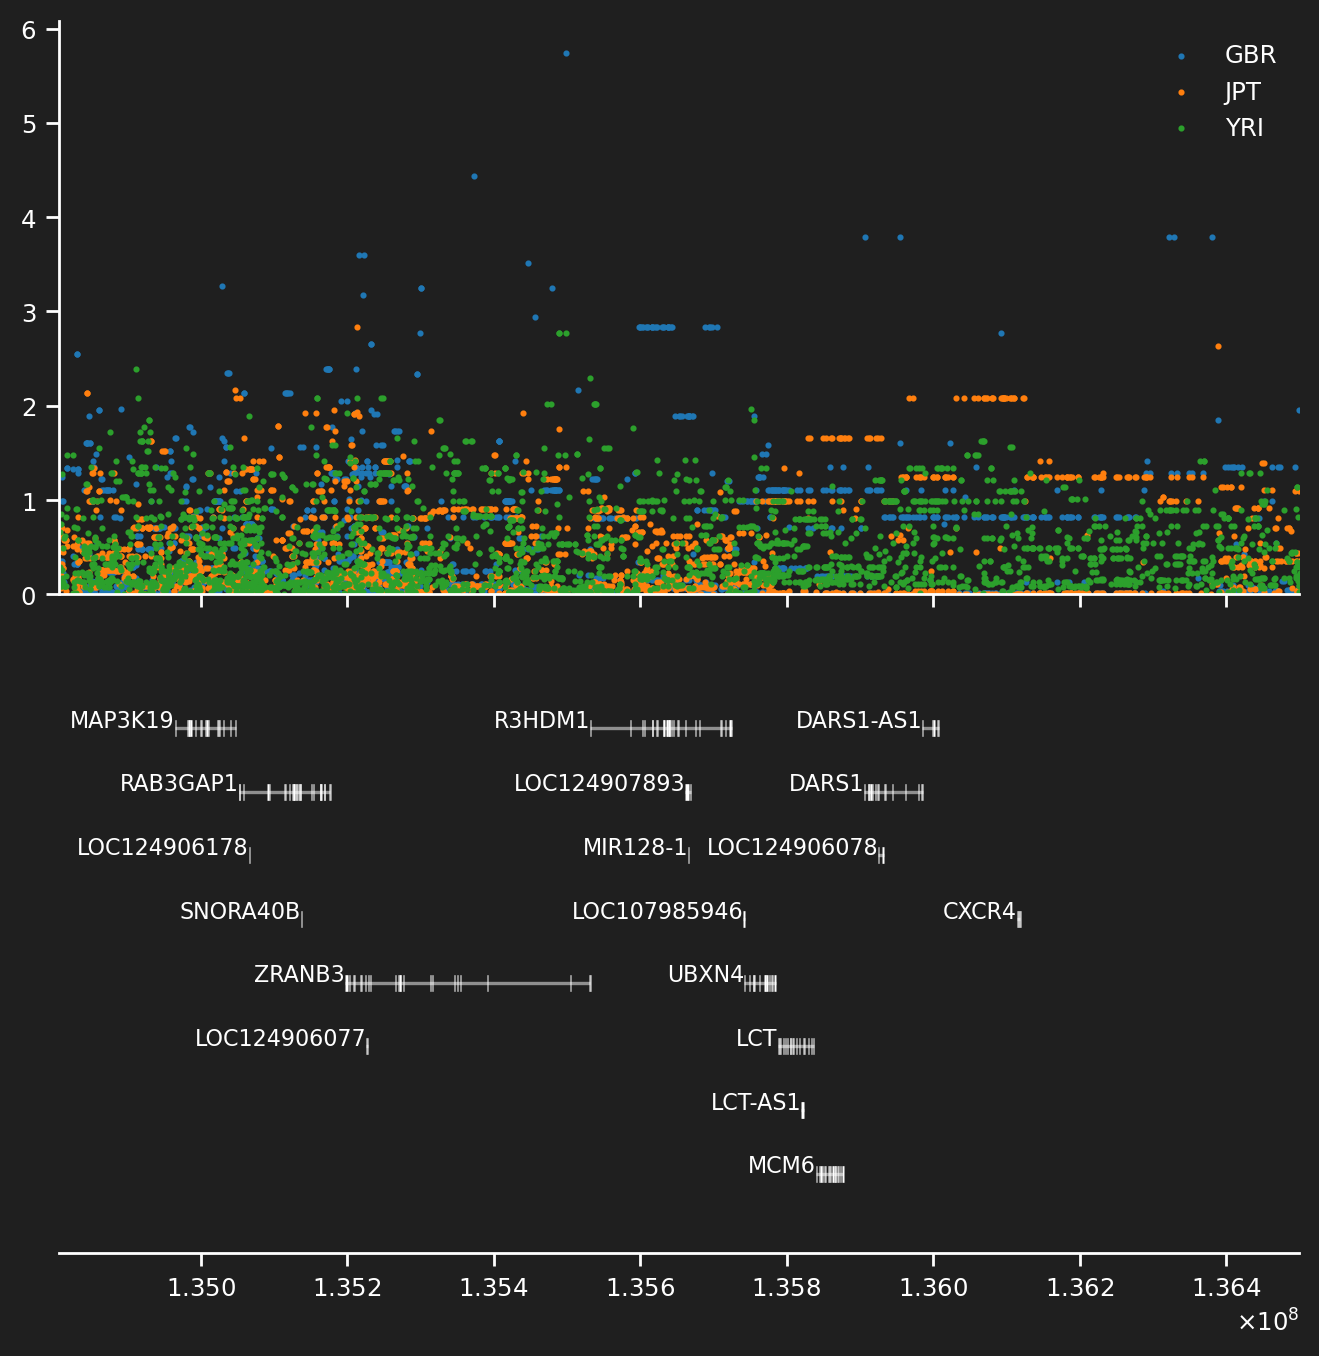

In [62]:
with vscode_theme(style='ticks'):
    ax = gene_plot('chr2', 135_000_000, 136_500_000, 'hg38', figsize=(8, 8))
    ax.scatter(gbr_df.pos, - gbr_df.when_mutation_has_freq2, s=2, c='tab:blue', label='GBR')
    ax.scatter(jpt_df.pos, - jpt_df.when_mutation_has_freq2, s=2, c='tab:orange', label='JPT')
    ax.scatter(yri_df.pos, - yri_df.when_mutation_has_freq2, s=2, c='tab:green', label='YRI')
    ax.set_ylim(bottom=0)
    ax.legend() ;

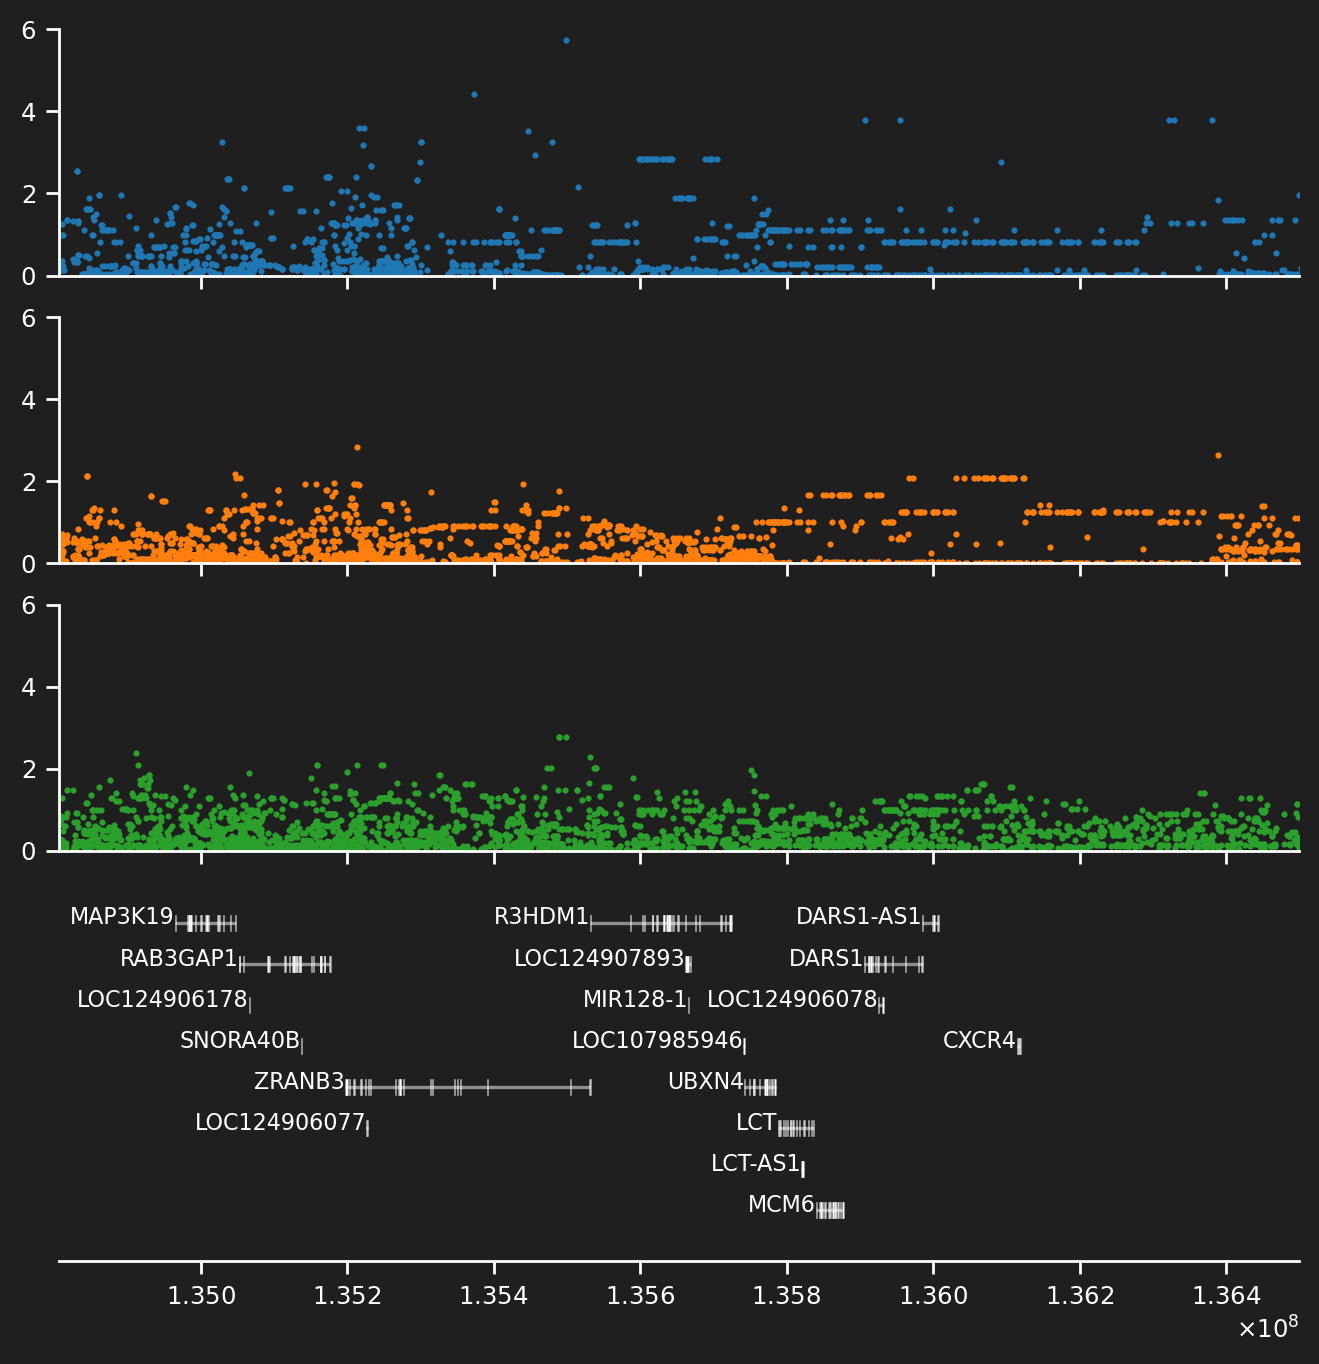

In [64]:
with vscode_theme(style='ticks'):
    ax = gene_plot('chr2', 135_000_000, 136_500_000, 'hg38', figsize=(8, 8), return_axes=3, aspect=0.5)

    ax[0].scatter(gbr_df.pos, - gbr_df.when_mutation_has_freq2, s=2, c='tab:blue', label='GBR')
    ax[0].set_ylim(0, 6)

    ax[1].scatter(jpt_df.pos, - jpt_df.when_mutation_has_freq2, s=2, c='tab:orange', label='JPT')
    ax[1].set_ylim(0, 6)

    ax[2].scatter(yri_df.pos, - yri_df.when_mutation_has_freq2, s=2, c='tab:green', label='YRI')
    ax[2].set_ylim(0, 6)



```bash
RelateFileFormats --mode ConvertToTreeSequence -i ../relate-tree-exercise/gbr_relate -o gbr_relate
RelateFileFormats --mode ConvertToTreeSequence -i ../relate-tree-exercise/jpt_relate -o jpt_relate
RelateFileFormats --mode ConvertToTreeSequence -i ../relate-tree-exercise/yri_relate -o yri_relate
```

## Analyzing tree sequences

`tskit` is a powerful library for working with tree sequences, which are data structures that efficiently represent the genealogical history of a set of DNA sequences. To load a tree sequence from a file, you can use the `tskit.load()` function. You can read all about `tskit` in its [documentation](https://tskit.dev).

Load the tree sequence for the GBR population:

In [71]:
import tskit
ts = tskit.load(f'gbr_relate.trees')

### Mutations and Sites

Mutations live on sites, and sites have positions. A site can have multiple mutations, so you get the site first:

In [ ]:
# Get site at a specific position
site = ts.site(position=pos)  # looks up by position

# All mutations at that site
for mut in site.mutations:
    print(mut.id, mut.node, mut.derived_state)

# If there's just one:
mut_id = site.mutations[0].id

8026 27012 G


If you need to search by approximate position or find the nearest site (SNP):


In [ ]:
pos = 130000000
positions = ts.sites_position  # array of all site positions
idx = np.searchsorted(positions, pos)
site = ts.site(idx)
for mut in site.mutations:
    print(site.position, mut.id, mut.node, mut.derived_state)

130000272.0 0 77 A


Or even better, find the position of the SNP with the smallest p-value:

In [ ]:
idx = np.argmin(gbr_df.when_mutation_has_freq2)
pos = gbr_df.iloc[idx].pos.item()
pos

(135498924.0, 8026, 27012, 'G')

Then get the site and the mutation at the site:

In [ ]:
site = ts.site(position=pos)
mut = site.mutations[0]
site.position, mut.id, mut.node, mut.derived_state

### Trees

Then find the corresponding position in the tree sequence:

In [ ]:
tree = ts.at(pos)
tree

How many samples carry this mutation with the lowest p-value?

In [85]:
list(tree.get_leaves(mut.node))

[31, 21, 30, 5, 25, 19, 34, 10, 11, 18, 27, 12, 28, 32, 23, 9, 33, 39, 20, 37]

What is the age of the mutation at this position? 

In [87]:
tree.time(mut.node)

603.9097900390625

### Plotting trees

The code below defines the `draw_tree` that you can use to visualize trees:

In [99]:
from itertools import takewhile
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from collections import defaultdict

def plot_tree(t, 
              ax=None, 
              leaf_colors=None, 
              show_node_ids=False, 
              show_mutations=True,
              fontsize=7, 
              alpha=1,
              text_offset=0, 
              leaf_order=None,
              margins=(0.5, 1, 0.5, 1), # top, right, bottom, left
              invert=False,
              log_scale=False,
              return_leaf_coords=False,
              align_labels=False,
              **kwargs): 

    if leaf_order is None:
        leaf_order = []
        for node in t.nodes(order="postorder"):        
            if t.is_leaf(node):
                leaf_order.append(node)

    return_ax = False
    if ax is None:   
        if 'figsize' not in kwargs:
            kwargs['figsize'] = (8, 5)
        return_ax = True
        fig, ax = plt.subplots(**kwargs)

    if log_scale:
        ax.set_xscale('symlog', base=10)

    branch_muts = defaultdict(list)
    for site in t.sites():
        for mut in site.mutations:
            branch_muts[mut.node].append(mut)
    mut_positions = {}  # mut.id -> (x, y)

    x_offsets = {}
    y_offsets = {}

    y_offset = len(list(t.leaves(t.root)))
    for node in t.nodes(order="preorder"):
        x_offsets[node] = t.time(node) 

    for node in leaf_order:
        y_offset -= 1
        y_offsets[node] = y_offset
            
    for node in t.nodes(order="postorder"):        
        if not t.is_leaf(node):
            children = t.children(node)
            y_offsets[node] = sum(y_offsets[x] for x in children) / len(children)

    horizontal_lines = list()
    vertical_lines = list()
    node_coords = list()
    leaf_coords = list()
    node_labels = list()
    max_x_offset = 0
    for node in t.nodes(order="postorder"):        
        max_x_offset = max(max_x_offset, x_offsets[node])
        node_coords.append((x_offsets[node], y_offsets[node]))
        if t.is_leaf(node):
            leaf_coords.append([str(node), x_offsets[node], y_offsets[node]])
        if not t.is_root(node):
            y = y_offsets[node]
            horizontal_lines.append(([x_offsets[t.parent(node)], x_offsets[node]], [y, y]))

            muts = branch_muts[node]
            parent = t.parent(node)
            t_child = t.time(node)
            t_parent = t.time(parent)
            n = len(muts)
            for i, mut in enumerate(muts):
                frac = (i + 1) / (n + 1)
                x = t_child + frac * (t_parent - t_child)
                # mut_positions[mut.id] = (-x, y)        
                mut_positions[mut.id] = (x, y)        

        if not t.is_leaf(node):
            c = sorted(t.children(node), key=lambda x: y_offsets[x])
            bottom, top = c[0], c[-1]
            x = x_offsets[node]
            vertical_lines.append(([x, x],[y_offsets[bottom], y_offsets[top]]))
            y = (y_offsets[bottom] + y_offsets[top]) / 2

            # strings =[str(x) for x in c]
            # prefix = ''.join(c[0] for c in takewhile(lambda x: all(x[0] == y for y in x), zip(*strings)))

            # df = data.loc[data.haplotype.str.startswith(prefix)]
            # suffix = f'({df.loc[df.case == 1].index.size}/{df.loc[df.case == 0].index.size})'

            # label  = prefix + ' ' + suffix
            # node.name = prefix
            # node_labels.append((-x, y, str(node)))
            node_labels.append((x, y, str(node)))

    # for i in range(len(horizontal_lines)):
    #     horizontal_lines[i][0][0] *= -1
    #     horizontal_lines[i][0][1] *= -1
    # for i in range(len(vertical_lines)):
    #     vertical_lines[i][0][0] *= -1
    #     vertical_lines[i][0][1] *= -1
    # for i in range(len(leaf_coords)):
    #     leaf_coords[i][1] *= -1

    if in_dark_theme(ax):
        foreground_color = 'white'
        label_color = 'grey'
        mut_color = 'hotpink'
    else:
        foreground_color = 'black'
        label_color = 'lightgrey'
        mut_color = 'hotpink'

    # draw the tree:
    for x in horizontal_lines:
        ax.plot(*x, c=foreground_color, linewidth=0.8, alpha=alpha)
    for x in vertical_lines:
        ax.plot(*x, c=foreground_color, linewidth=0.8, alpha=alpha)

    if show_node_ids:
        d = 0#max_x_offset / 200
        d = -d if invert else d
        for x, y, txt in node_labels:
            ax.text(x-d, y, txt, fontsize=fontsize, 
                    horizontalalignment='left' if invert else 'right',
                    verticalalignment='bottom', color=label_color)

    for name, x, y in leaf_coords:
                
        if align_labels:
            ax.text(0+text_offset, y, name, fontsize=fontsize,
                    verticalalignment='center', horizontalalignment='right' if invert else 'left')
            if leaf_colors is None:
                color = 'black'
            else:
                color = leaf_colors[name]
            ax.plot(x, y, c=color, marker="o", ms=3)
            ax.add_line(Line2D((x, text_offset), (y, y), linewidth=0.8, color='grey', linestyle='dashed', zorder=0))
        else:
            ax.text(x+text_offset, y, name, fontsize=fontsize,
                    verticalalignment='center', horizontalalignment='right' if invert else 'left'
                    )
            if leaf_colors is None:
                color = 'black'
            else:
                color = leaf_colors[name]
            ax.plot(x, y, c=color, marker="o", ms=3)

    if show_mutations:
        mutation_markers = []
        for node in t.nodes(order="postorder"):
            if node in mut_positions:
                mutation_markers.append(mut_positions[node])
        if mutation_markers:
            ax.scatter(*zip(*mutation_markers), c=mut_color, marker="x", s=30, zorder=10)

    # ax.set_xlim(-margins[3]-max_x_offset, margins[1])
    # ax.set_ylim(-margins[2], len(leaf_coords)-1+margins[0])
    ax.set_xlim(margins[3]+max_x_offset, margins[1])
    ax.set_ylim(-margins[2], len(leaf_coords)-1+margins[0])

    ax.get_yaxis().set_visible(False)

    ax.spines['top'].set_visible(False) 
    ax.spines['left'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    if invert:
        ax.invert_xaxis()

    ret_val = []
    if return_ax:
        ret_val.append(ax)
    if return_leaf_coords:
        ret_val.append(leaf_coords)
    if ret_val:
        return ret_val
    # plt.tight_layout()
    plt.show()    

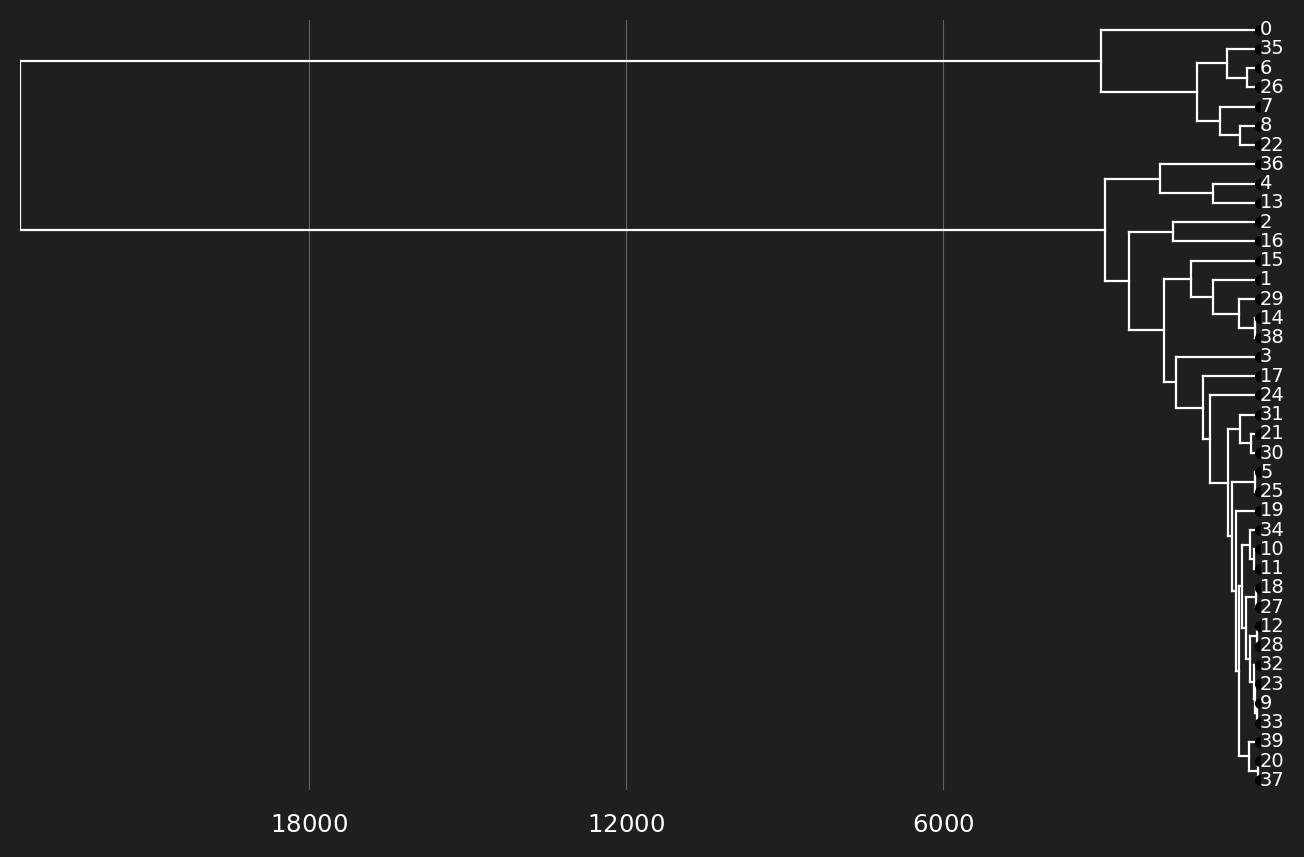

In [104]:
plot_tree(tree) ;

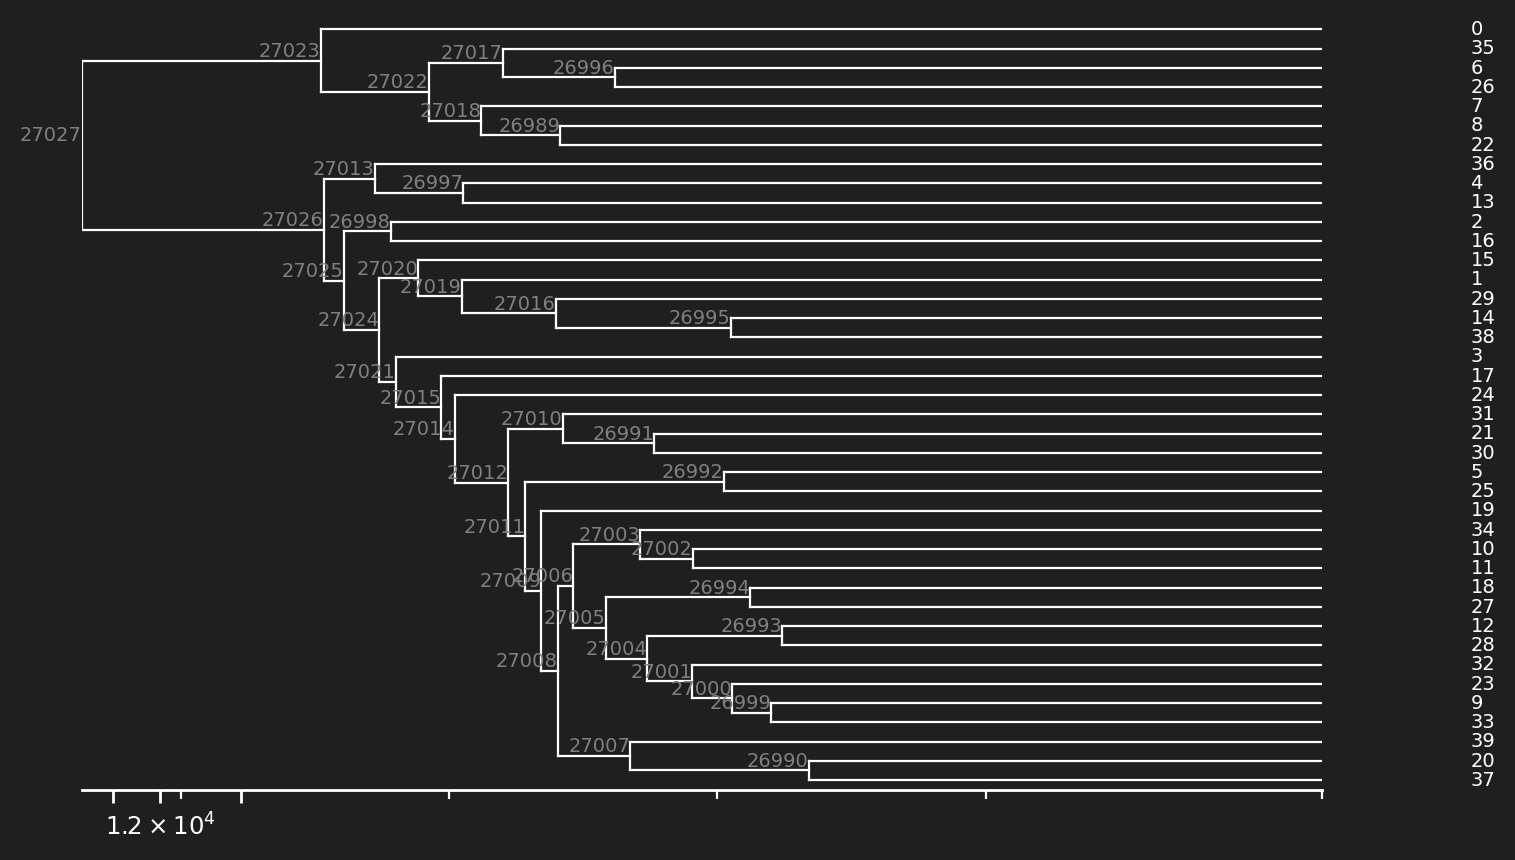

In [ ]:
plot_tree(tree, figsize=(8, 5), show_node_ids=True, log_scale=True)

## Full chr2 analysis of full 1000 genomes data set

| Tag | Name                 | Region    | Location                      |
|:----|:---------------------|:----------|:------------------------------|
| GWD | Gambian              | Africa    | Gambian in Western Division, The Gambia  |
| MSL | Mende                | Africa    | Mende in Sierra Leone |
| ESN | Esan                 | Africa    | Esan in Nigeria |
| LWK | Luhya                | Africa    | Luhya in Webuye, Kenya |
| YRI | Yoruba               | Africa    | Yoruba in Ibadan, Nigeria |
| CEU | CEPH                 | Europe    | Utah residents (CEPH) with Northern and Western European ancestry  |
| TSI | Tuscan               | Europe    | Toscani in Italia  |
| GBR | British              | Europe    | British in England and Scotland  |
| FIN | Finnish              | Europe    | Finnish in Finland  |
| IBS | Spanish              | Europe    | Iberian populations in Spain  |
| GIH | Gujarati             | SouthAsia | Gujarati Indian in Houston, TX |
| PJL | Punjabi              | SouthAsia | Punjabi in Lahore, Pakistan |
| BEB | Bengali              | SouthAsia | Bengali in Bangladesh |
| STU | Sri Lankan           | SouthAsia | Sri Lankan Tamil in the UK |
| ITU | Indian               | SouthAsia | Indian Telugu in the UK |
| CHB | Han Chinese          | EastAsia  | Han Chinese in Beijing, China |
| JPT | Japanese             | EastAsia  | Japanese in Tokyo, Japan |
| CHS | Southern Han Chinese | EastAsia  | Han Chinese South |
| CDX | Dai Chinese          | EastAsia  | Chinese Dai in Xishuangbanna, China |
| KHV | Kinh Vietnamese      | EastAsia  | Kinh in Ho Chi Minh City, Vietnam |
| CHD | Denver Chinese       | EastAsia  | Chinese in Denver, Colorado (pilot 3 only) |
| ASW | African-American SW  | America   | African Ancestry in Southwest US   |
| ACB | African-Caribbean    | America   | African Caribbean in Barbados |
| MXL | Mexican-American     | America   | Mexican Ancestry in Los Angeles, California |
| PUR | Puerto Rican         | America   | Puerto Rican in Puerto Rico |
| CLM | Colombian            | America   | Colombian in Medellin, Colombia |
| PEL | Peruvian             | America   | Peruvian in Lima, Peru |

In [ ]:
chr2_1000g = pd.read_parquet('relate_log10pvals_1000g_pops.parquet')

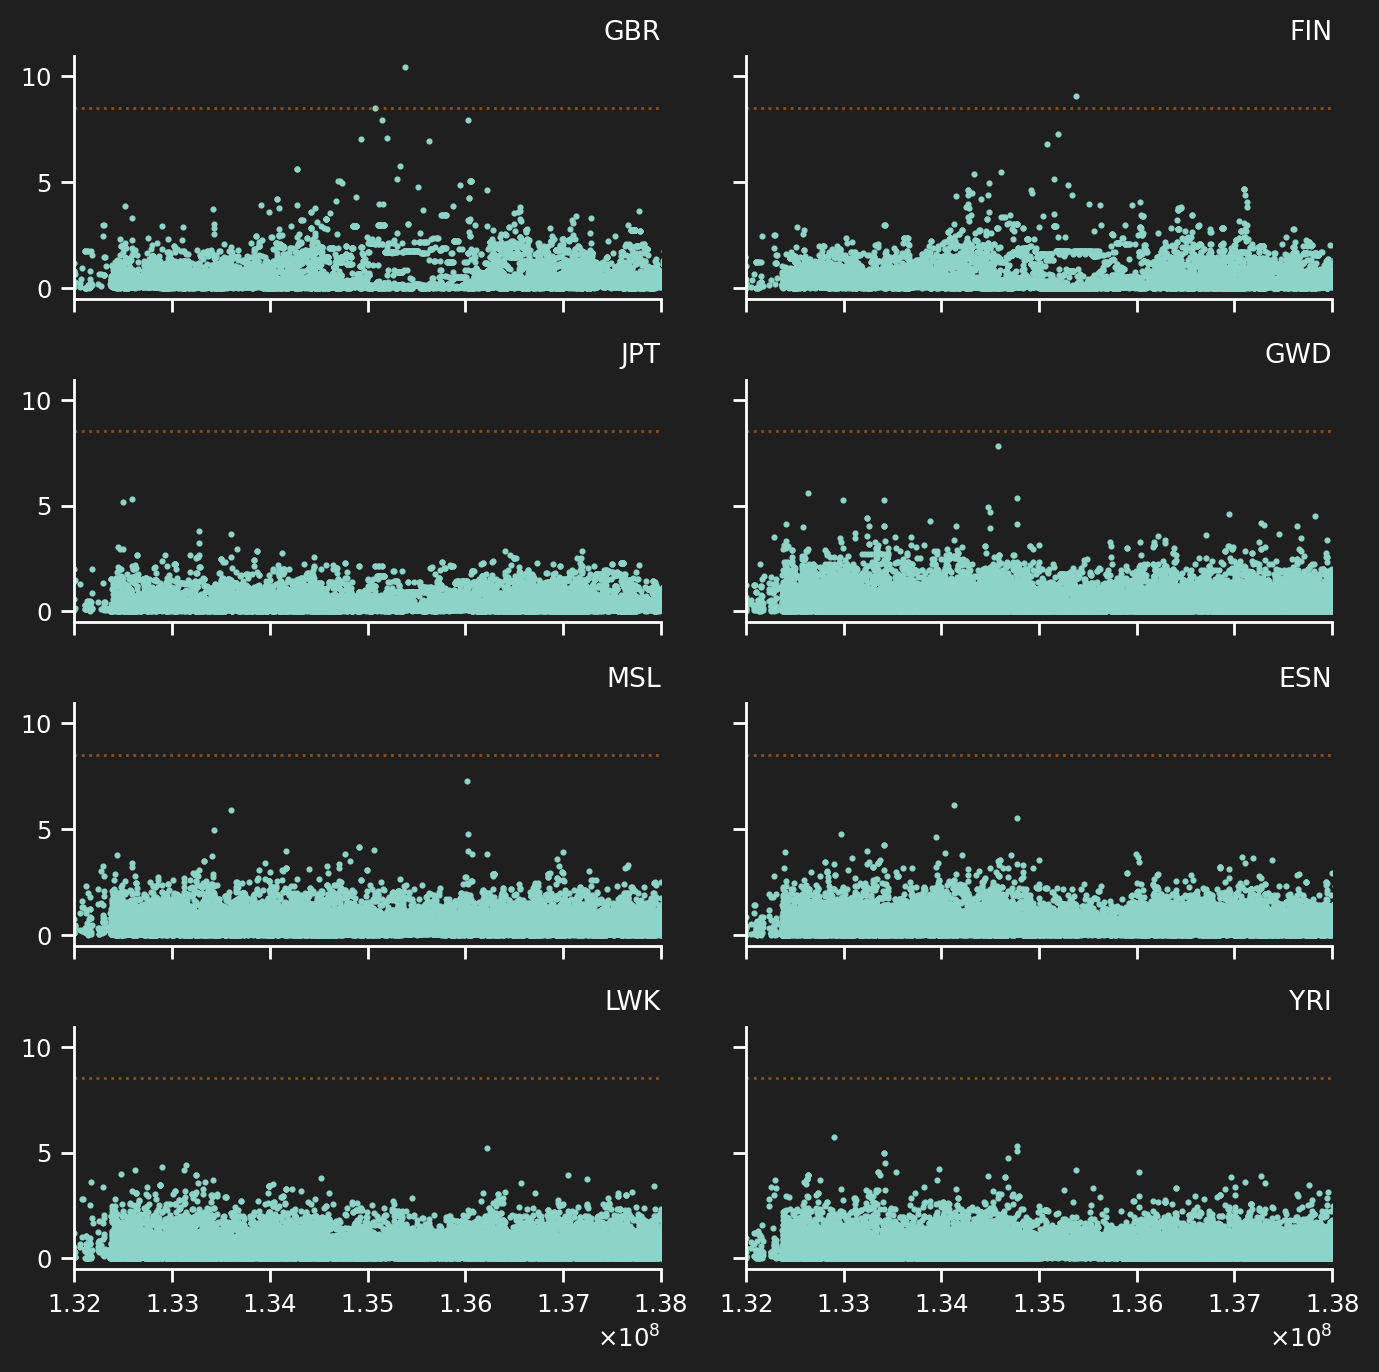

In [107]:
snp_pos = 0
with vscode_theme(style='ticks'):
    pops = ['GBR', 'FIN', 'JPT', 'GWD', 'MSL', 'ESN', 'LWK','YRI']
    fig, axes = plt.subplots(4, 2, figsize=(7, 7), sharex=True, sharey=True)
    axes[0, 0].set_xlim(132_000_000, 138_000_000)
    for pop, ax in zip(pops, axes.flat):
        ax.scatter(chr2_1000g.pos, - chr2_1000g[pop], s=2)
        ax.set_title(pop)
        ax.axhline(y=8.5, color='tab:orange', linestyle='dotted', lw=1, alpha=0.5)
        ax.axvline(x=snp_pos, color='red', linestyle='dashed')

    plt.tight_layout()

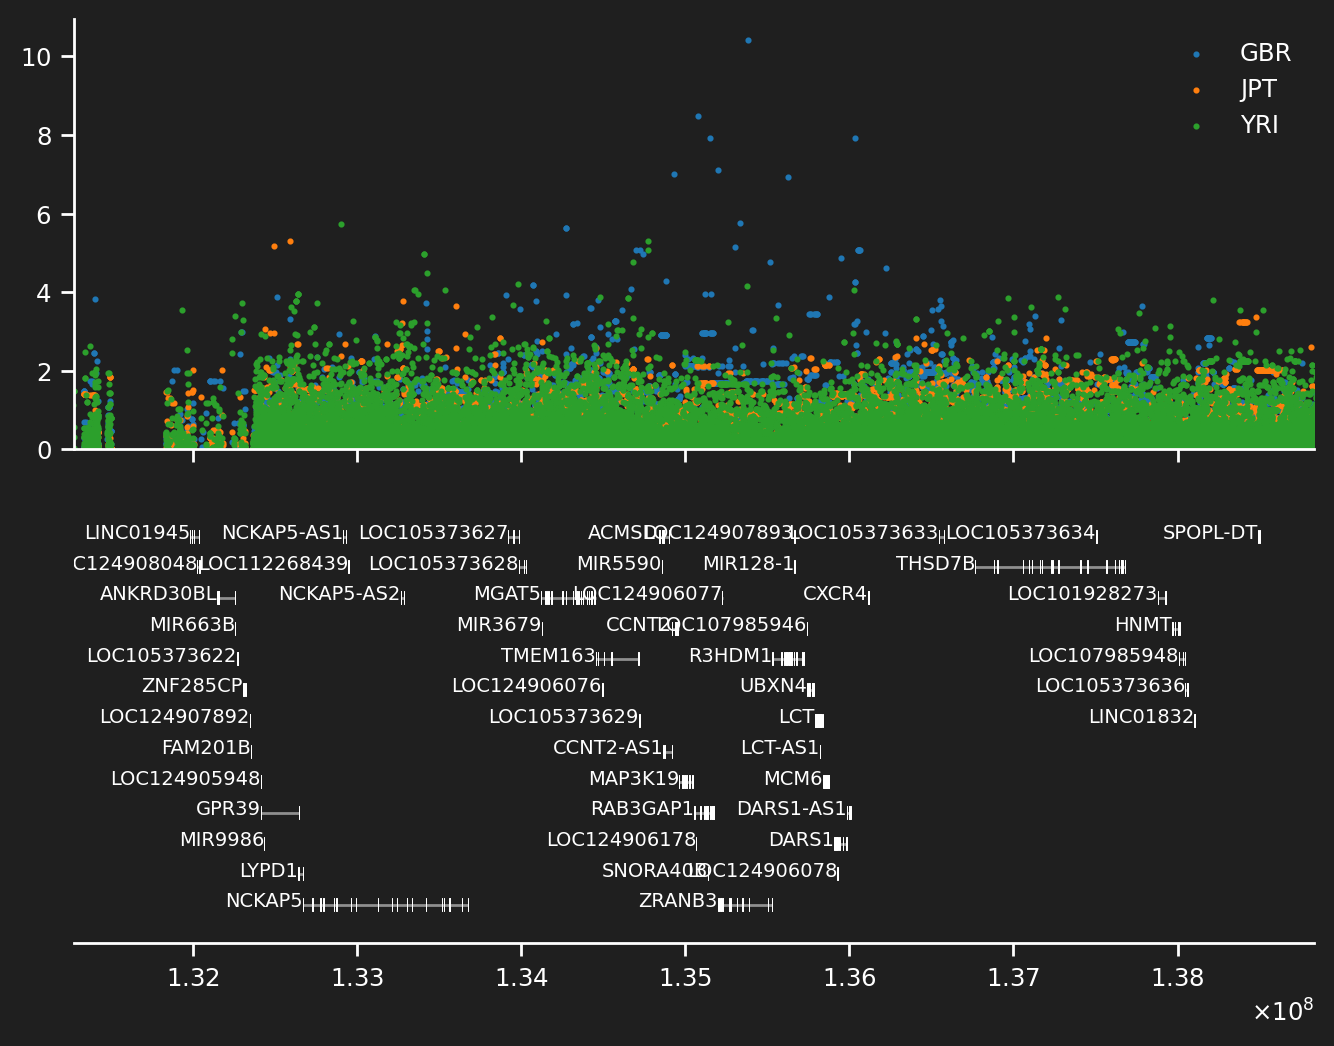

In [106]:
with vscode_theme(style='ticks'):
    ax = gene_plot('chr2', 132_000_000, 138_500_000, 'hg38', figsize=(8, 6))
    ax.scatter(chr2_1000g.pos, - chr2_1000g.GBR, s=2, c='tab:blue', label='GBR')
    ax.scatter(chr2_1000g.pos, - chr2_1000g.JPT, s=2, c='tab:orange', label='JPT')
    ax.scatter(chr2_1000g.pos, - chr2_1000g.YRI, s=2, c='tab:green', label='YRI')
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper right') ;